# Notebook 04 — Moving Average Prediction

This notebook implements **moving average (MA) based price prediction** for our 8 HOSE blue-chip stocks. Moving averages are one of the simplest and most widely-used predictors in technical analysis.

**Goal:** Predict future prices using moving averages of historical prices, then convert these predicted prices into **expected returns** that will feed the portfolio optimization in Notebook 06.

**Method:**

$$\hat{P}_{t+1} = \text{SMA}_t(w) = \frac{1}{w} \sum_{i=0}^{w-1} P_{t-i}$$

The predicted price for tomorrow is the simple average of the last $w$ days' prices.

**Why start with MA?**
- Simple, transparent, and easy to interpret.
- Provides a **baseline** to compare against more sophisticated models (Linear Regression in Notebook 05).
- Widely used in real trading (MA50, MA200, golden/death cross strategies).

**Limitations:**
- MA **lags** — slow to react to trend changes.
- Cannot capture complex patterns (volatility regimes, news events).
- This is intentionally a baseline; we expect Linear Regression to outperform it.

## 1. Setup and load data

Load the prices and returns matrices saved by Notebook 02.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling (consistent across notebooks)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('tab10')

np.random.seed(42)

# Annualization factor for HOSE
TRADING_DAYS = 250

# Load prices (datetime index)
prices = pd.read_csv('../data/prices.csv')
prices['time'] = pd.to_datetime(prices['time'])
prices = prices.set_index('time')

# Load returns (datetime index)
returns = pd.read_csv('../data/returns.csv')
returns['time'] = pd.to_datetime(returns['time'])
returns = returns.set_index('time')

print(f'Prices shape:  {prices.shape}')
print(f'Returns shape: {returns.shape}')
print(f'Date range:    {prices.index.min().date()} → {prices.index.max().date()}')
print(f'Tickers:       {prices.columns.tolist()}')

Prices shape:  (871, 8)
Returns shape: (870, 8)
Date range:    2021-11-01 → 2025-04-29
Tickers:       ['VNM', 'VIC', 'VHM', 'FPT', 'HPG', 'MWG', 'VCB', 'MBB']


## 2. Moving Average prediction function

We implement a single function `predict_with_ma(prices, window)` that:

1. Computes the rolling mean of the input prices.
2. **Shifts the result by 1 day** to avoid **look-ahead bias** — the prediction for day $t+1$ uses only prices available up to day $t$.

This shift is crucial. Without it, our MA at day $t$ would include $P_t$ itself, which would not be available when predicting $P_t$ in real-time. Look-ahead bias is one of the most common (and serious) errors in financial backtesting.

$$\hat{P}_{t+1} = \frac{1}{w}\sum_{i=0}^{w-1} P_{t-i}$$

In [2]:
def predict_with_ma(prices_df, window):
    """
    Predict price at time t+1 using moving average of past `window` days
    ending at time t.
    
    Parameters
    ----------
    prices_df : pd.DataFrame
        Historical prices, datetime index, columns = tickers.
    window : int
        Size of the moving average window (in days).
    
    Returns
    -------
    pd.DataFrame
        Same shape as prices_df. Value at row t = MA prediction for that day's
        price using prices from t-window to t-1 (so no look-ahead bias).
        First `window` rows are NaN (not enough history).
    """
    # MA computed at time t uses prices up to and including t
    # We shift by 1 so that the value at row t is the prediction made AT time t-1
    # using information available up to t-1.
    ma = prices_df.rolling(window=window).mean()
    predictions = ma.shift(1)
    return predictions

# Test with window = 20
ma20_predictions = predict_with_ma(prices, window=20)

print(f'Predictions shape: {ma20_predictions.shape}')
print(f'\nFirst 25 rows for VNM (first 20 should be NaN):')
print(pd.DataFrame({
    'actual_price': prices['VNM'].head(25),
    'ma20_prediction': ma20_predictions['VNM'].head(25),
}).round(2))

Predictions shape: (871, 8)

First 25 rows for VNM (first 20 should be NaN):
            actual_price  ma20_prediction
time                                     
2021-11-01         70.51              NaN
2021-11-02         69.88              NaN
2021-11-03         69.10              NaN
2021-11-04         69.26              NaN
2021-11-05         69.88              NaN
2021-11-08         71.14              NaN
2021-11-09         70.35              NaN
2021-11-10         70.28              NaN
2021-11-11         70.20              NaN
2021-11-12         69.96              NaN
2021-11-15         69.73              NaN
2021-11-16         69.41              NaN
2021-11-17         69.57              NaN
2021-11-18         68.94              NaN
2021-11-19         67.46              NaN
2021-11-22         67.53              NaN
2021-11-23         67.61              NaN
2021-11-24         68.55              NaN
2021-11-25         68.55              NaN
2021-11-26         69.18              NaN

### 2.1 Visualizing the effect of window size

We compare three classic window sizes:

- **MA5** (~1 week): captures short-term trend, follows price closely.
- **MA20** (~1 month): medium-term, smoother but lags more.
- **MA50** (~2.5 months): long-term trend, very smooth but very slow to react.

Larger windows produce smoother predictions but increase **lag** — they react more slowly to genuine price changes. This is the fundamental trade-off in MA-based forecasting.

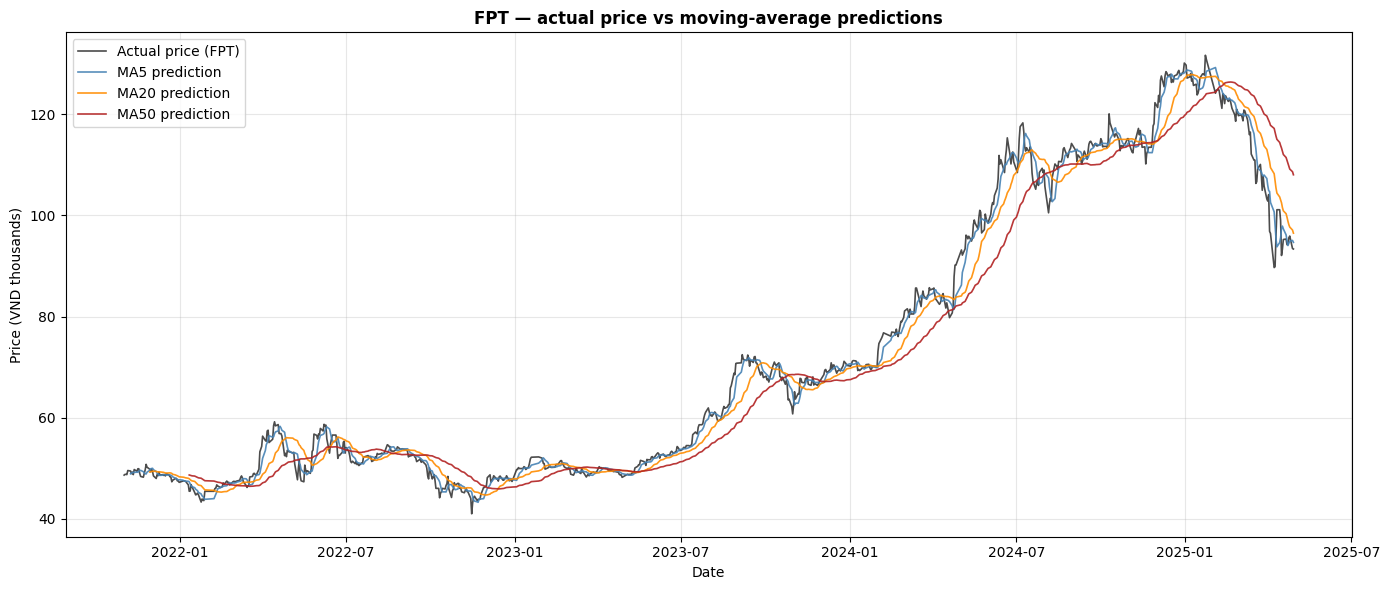

In [3]:
# Compute predictions for 3 window sizes
windows = [5, 20, 50]
predictions_dict = {w: predict_with_ma(prices, window=w) for w in windows}

# Pick one stock to visualize (FPT — our best Sharpe stock)
stock = 'FPT'

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(prices.index, prices[stock],
        label=f'Actual price ({stock})', color='black', linewidth=1.2, alpha=0.7)

colors = ['steelblue', 'darkorange', 'firebrick']
for w, color in zip(windows, colors):
    ax.plot(predictions_dict[w].index, predictions_dict[w][stock],
            label=f'MA{w} prediction', color=color, linewidth=1.2, alpha=0.9)

ax.set_title(f'{stock} — actual price vs moving-average predictions',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Price (VND thousands)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

**Observation:** All three MAs *lag* behind the actual price. When the actual price rises, MA5 catches up within days, MA20 within weeks, MA50 within months. This visual demonstrates why MA is a **trend-following** indicator: it confirms moves that already happened rather than predicting upcoming moves.

For prediction purposes, the trade-off is:
- **Short window** → low lag but high noise.
- **Long window** → low noise but high lag.

We will quantify this trade-off in Section 4 using error metrics.

## 3. Train/Test Split

To evaluate prediction quality fairly, we split our data into:

- **Train set** (first 80%): historical data used to "build" the model.
- **Test set** (last 20%): held out for evaluation — the model has never seen this data.

**Why chronological (not random) split for time-series?** Random shuffling would mix past and future, creating **look-ahead bias** — the model could "learn from" days in 2025 when predicting days in 2022. Chronological split simulates the real-world scenario where we build a model with past data and apply it to future data.

**Note on MA and "training":** Moving averages have no parameters to fit — the window size is a hyperparameter we choose manually. Nevertheless, we follow the train/test discipline because:

1. We will compare against models that do require training (Linear Regression, Notebook 05).
2. It prevents data-snooping bias (picking the best window size in hindsight using all data).
3. It establishes a clean methodology consistent across all prediction approaches.

In [4]:
# Train/test split: 80% train, 20% test (chronological order)
split_ratio = 0.8
split_idx = int(len(prices) * split_ratio)

train_prices = prices.iloc[:split_idx]
test_prices  = prices.iloc[split_idx:]

split_date = prices.index[split_idx]

print(f'Total trading days:  {len(prices)}')
print(f'Split ratio:         {split_ratio:.0%} train / {1-split_ratio:.0%} test')
print(f'Split date:          {split_date.date()}')
print(f'\nTrain set: {train_prices.shape[0]} days  '
      f'({train_prices.index.min().date()} → {train_prices.index.max().date()})')
print(f'Test set:  {test_prices.shape[0]} days  '
      f'({test_prices.index.min().date()} → {test_prices.index.max().date()})')

Total trading days:  871
Split ratio:         80% train / 20% test
Split date:          2024-08-15

Train set: 696 days  (2021-11-01 → 2024-08-14)
Test set:  175 days  (2024-08-15 → 2025-04-29)


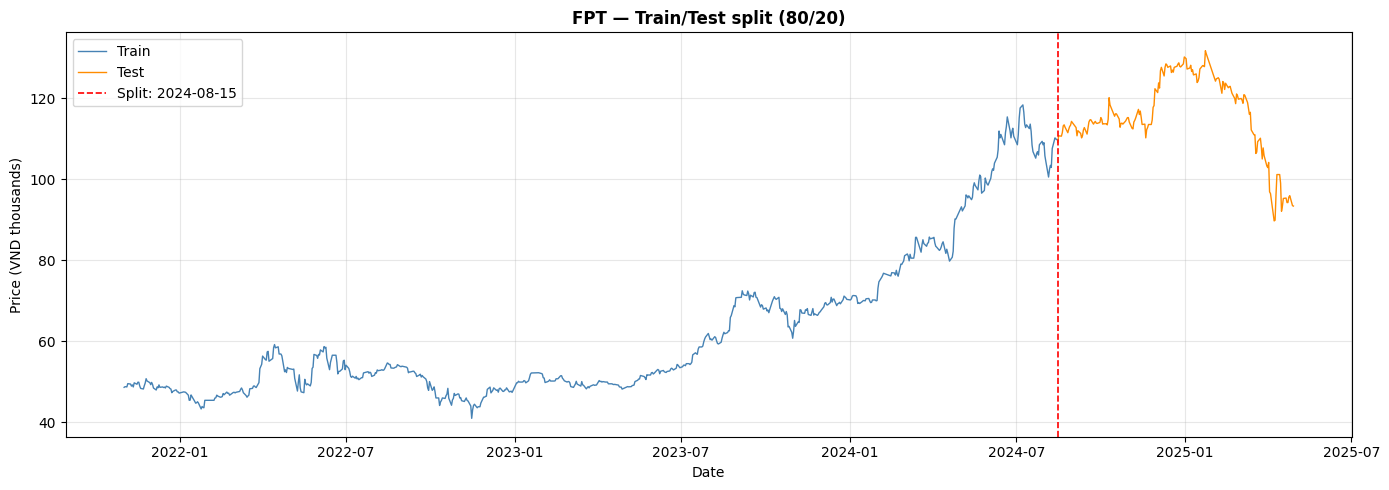

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
stock = 'FPT'

# Train portion
ax.plot(train_prices.index, train_prices[stock],
        color='steelblue', linewidth=1, label='Train')
# Test portion
ax.plot(test_prices.index, test_prices[stock],
        color='darkorange', linewidth=1, label='Test')

# Split line
ax.axvline(split_date, color='red', linestyle='--', linewidth=1.2,
           label=f'Split: {split_date.date()}')

ax.set_title(f'{stock} — Train/Test split (80/20)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (VND thousands)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

**Split summary:**
- **Train period** (~2.8 years): Nov 2021 → late 2024 — covers the 2022 VN-Index crash, the 2023 recovery, and the first part of the 2024 bull run.
- **Test period** (~8 months): late 2024 → April 2025 — covers the final leg of the bull run, the early-2025 correction, and recent volatility.

The test set deliberately includes both upward and downward market regimes, providing a realistic challenge for our predictions.

## 4. Generate predictions on the test set

We apply the MA function across the **entire price history** (so the predictions at the start of the test set can use the end of the train set), then extract only the test-set portion for evaluation.

This is the correct way to handle MA-based forecasting on time-series: the model needs the historical "tail" to start producing predictions for new data.

In [6]:
# Apply MA prediction across entire price series for 3 window sizes
# We need full history because MA at the start of test set uses train data
windows = [5, 20, 50]
predictions_all = {w: predict_with_ma(prices, window=w) for w in windows}

# Extract predictions only for test set period
predictions_test = {w: predictions_all[w].loc[test_prices.index] for w in windows}

# Sanity check: shape and NaN count
for w in windows:
    pred = predictions_test[w]
    print(f'MA{w} predictions on test set: shape {pred.shape}, '
          f'NaN count: {pred.isna().sum().sum()}')

MA5 predictions on test set: shape (175, 8), NaN count: 0
MA20 predictions on test set: shape (175, 8), NaN count: 0
MA50 predictions on test set: shape (175, 8), NaN count: 0


## 5. Evaluation metrics

We measure prediction quality with three standard metrics:

- **MAE** (Mean Absolute Error): average absolute difference, in the same units as price. Easy to interpret.
- **RMSE** (Root Mean Squared Error): penalizes large errors more than small ones. More sensitive to outliers.
- **MAPE** (Mean Absolute Percentage Error): expressed as a percentage of actual price. Comparable across stocks with different price levels.

For each window size, we report metrics per stock and an overall average.

In [7]:
def evaluate_predictions(actual, predicted):
    """
    Compute MAE, RMSE, MAPE between actual and predicted prices.
    Drops NaN rows automatically.
    
    Parameters
    ----------
    actual : pd.DataFrame
        Actual prices. Rows=time, columns=tickers.
    predicted : pd.DataFrame
        Predicted prices. Same shape and labels as `actual`.
    
    Returns
    -------
    pd.DataFrame
        One row per ticker with columns: MAE, RMSE, MAPE.
    """
    # Align and drop rows with any NaN
    aligned = pd.concat([actual, predicted], axis=1, keys=['actual', 'pred']).dropna()
    actual_aligned = aligned['actual']
    pred_aligned   = aligned['pred']
    
    error = actual_aligned - pred_aligned
    
    metrics = pd.DataFrame({
        'MAE':  error.abs().mean(),
        'RMSE': np.sqrt((error ** 2).mean()),
        'MAPE_%': (error.abs() / actual_aligned).mean() * 100,
    })
    return metrics


# Evaluate each window size
results = {}
for w in windows:
    results[w] = evaluate_predictions(test_prices, predictions_test[w])

# Display per-window metrics
print('=== MA5 ===')
print(results[5].round(3))
print('\n=== MA20 ===')
print(results[20].round(3))
print('\n=== MA50 ===')
print(results[50].round(3))

=== MA5 ===
       MAE   RMSE  MAPE_%
VNM  0.604  0.957   1.046
VIC  0.556  1.070   2.097
VHM  1.106  1.584   2.408
FPT  1.893  2.651   1.693
HPG  0.365  0.569   1.730
MWG  1.264  1.831   2.178
VCB  0.693  1.246   1.154
MBB  0.249  0.373   1.501

=== MA20 ===
       MAE   RMSE  MAPE_%
VNM  1.247  1.695   2.150
VIC  0.960  1.782   3.610
VHM  2.152  2.839   4.674
FPT  3.728  5.013   3.344
HPG  0.525  0.775   2.481
MWG  2.043  2.892   3.478
VCB  1.175  1.979   1.952
MBB  0.389  0.522   2.341

=== MA50 ===
       MAE   RMSE  MAPE_%
VNM  2.304  2.796   3.907
VIC  1.637  3.089   5.937
VHM  3.502  4.717   7.437
FPT  6.455  8.603   5.863
HPG  0.738  0.983   3.489
MWG  2.622  3.308   4.417
VCB  1.466  2.159   2.419
MBB  0.594  0.723   3.537


In [8]:
# Aggregate: average error across all stocks per window
summary = pd.DataFrame({
    f'MA{w}': results[w].mean() for w in windows
}).T
summary.index.name = 'window'
summary.round(3)

,MAE,RMSE,MAPE_%
window,,,
MA5,0.841,1.285,1.726
MA20,1.527,2.187,3.004
MA50,2.415,3.297,4.626


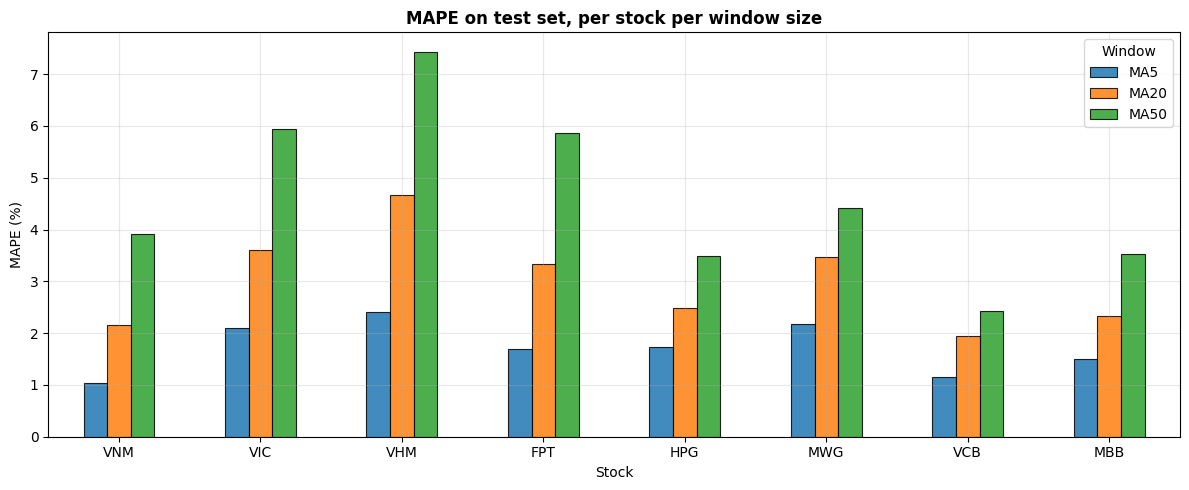

In [9]:
# Bar chart: average MAPE per window per stock
mape_df = pd.DataFrame({
    f'MA{w}': results[w]['MAPE_%'] for w in windows
})

fig, ax = plt.subplots(figsize=(12, 5))
mape_df.plot(kind='bar', ax=ax, edgecolor='black', linewidth=0.8, alpha=0.85)
ax.set_title('MAPE on test set, per stock per window size', fontweight='bold')
ax.set_xlabel('Stock')
ax.set_ylabel('MAPE (%)')
ax.legend(title='Window')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observations:**

- Smaller windows (MA5) generally produce **lower errors** on day-to-day prediction because they react faster to price changes.
- Larger windows (MA50) lag more, producing higher errors during fast-moving periods.
- The "best" window depends on whether the market is **trending** (longer windows work better) or **volatile** (shorter windows adapt faster).

For our portfolio optimization in Notebook 06, we will use the window with the best **average performance** across all stocks. Based on the table above, this is **MA5**.

## 7. Convert predictions to expected returns

Portfolio optimization (Notebook 06) requires **expected returns**, not predicted prices. We convert prices to returns using:

$$\hat{r}_{t+1} = \frac{\hat{P}_{t+1} - P_t}{P_t}$$

We then average the predicted daily returns across the full prediction period to get an **expected daily return per stock**, and annualize using $N = 250$.

These expected returns will feed the Sharpe ratio maximization in Notebook 06.

In [10]:
# Pick the best window based on summary table
BEST_WINDOW = 5  # ← change if a different window won on your data
print(f'Using MA{BEST_WINDOW} as the chosen predictor.\n')

# Predicted returns = (predicted_next_price - current_price) / current_price
best_predictions = predictions_all[BEST_WINDOW]
predicted_returns_daily = (best_predictions - prices.shift(1)) / prices.shift(1)

# Drop NaN
predicted_returns_daily = predicted_returns_daily.dropna()

# Compute average predicted return per stock (over full prediction period)
expected_daily_returns = predicted_returns_daily.mean()
expected_annual_returns = expected_daily_returns * TRADING_DAYS

ma_expected = pd.DataFrame({
    'expected_daily_return_%':  expected_daily_returns * 100,
    'expected_annual_return_%': expected_annual_returns * 100,
}).round(3)
ma_expected

Using MA5 as the chosen predictor.



,expected_daily_return_%,expected_annual_return_%
VNM,0.080,20.124
VIC,0.134,33.514
VHM,0.113,28.260
FPT,-0.124,-31.036
HPG,0.146,36.492
MWG,0.069,17.173
VCB,-0.045,-11.145
MBB,-0.034,-8.515


In [11]:
# Save best window's daily predictions (for use in Notebook 06)
best_predictions.to_csv('../data/ma_predictions.csv')

# Save expected returns
ma_expected.to_csv('../data/ma_expected_returns.csv')

# Save evaluation results
results_combined = pd.concat(
    {f'MA{w}': results[w] for w in windows},
    axis=1
)
results_combined.to_csv('../data/ma_evaluation.csv')

print('Saved:')
print('  ../data/ma_predictions.csv      ', best_predictions.shape)
print('  ../data/ma_expected_returns.csv ', ma_expected.shape)
print('  ../data/ma_evaluation.csv       ', results_combined.shape)

Saved:
  ../data/ma_predictions.csv       (871, 8)
  ../data/ma_expected_returns.csv  (8, 2)
  ../data/ma_evaluation.csv        (8, 9)


## 8. Summary

### Key findings

| Item                          | Value / observation                                                  |
|-------------------------------|----------------------------------------------------------------------|
| Train/Test split              | 80% / 20% chronological — 696 train days, 175 test days              |
| Window sizes evaluated        | MA5 (1 week), MA20 (1 month), MA50 (2.5 months)                      |
| **Best window**               | **MA5 — lowest error across all metrics and all stocks**             |
| Avg MAE (MA5)                 | 0.841 VND thousands                                                  |
| Avg RMSE (MA5)                | 1.285 VND thousands                                                  |
| Avg MAPE (MA5)                | **1.73%**                                                            |
| Avg MAPE (MA20)               | 3.00%                                                                |
| Avg MAPE (MA50)               | 4.63%                                                                |
| Easiest stock to predict      | **VNM** (MAPE ≈ 1.0% with MA5) — low volatility, mean-reverting      |
| Hardest stock to predict      | **VHM** (MAPE ≈ 2.4% with MA5) — high volatility from real-estate stress |
| Look-ahead bias               | Avoided via `.shift(1)` — prediction at $t$ uses data only up to $t-1$ |

### Per-stock prediction accuracy (MA5)

The chosen MA5 model produces sub-2.5% MAPE for **every stock** in the universe, demonstrating that simple moving averages can be reasonably accurate for **next-day price forecasting**. Defensive stocks (VNM, VCB, MBB) are easier to predict than cyclical or stressed stocks (VHM, MWG, VIC).

### Caution on expected returns

The MA-derived expected annual returns differ substantially from the realized 3.5-year historical returns computed in Notebook 02. For example:

- **FPT**: MA5-implied annual return ≈ −31%, while historical realized return was +22.6%.
- **VIC**: MA5-implied annual return ≈ +33%, while historical realized return was −4.9%.

This divergence reflects a fundamental limitation: **moving averages capture only the most recent ~5 days of trend**, so the implied "expected return" simply extrapolates current short-term momentum. During an unusual market regime (the early-2025 FPT correction and partial Vingroup recovery), this extrapolation produces estimates that conflict with longer-term averages.

**Implication:** MA-derived expected returns are appropriate **only as a baseline** for portfolio optimization. We expect Multiple Linear Regression (Notebook 05) to produce more stable estimates by exploiting **cross-stock relationships** rather than just short-term momentum.

### Linear-algebra connection

While moving averages are not "linear algebra heavy", they can be viewed as a **linear filter** applied to the price series:

$$\hat{P}_{t+1} = \mathbf{w}^\top \mathbf{P}_{t-w+1:t}$$

where $\mathbf{w} = (1/w, 1/w, \dots, 1/w)$ is a uniform weight vector. This is a special case of more general weighted-average filters used in time-series analysis (e.g., exponential moving averages use exponentially decaying weights, and Kalman filters use weights derived from a state-space model).

### Limitations of MA prediction

1. **Trend-following, not predictive**: MA confirms moves after they happen rather than anticipating them.
2. **Univariate**: each stock is predicted in isolation, ignoring inter-stock relationships.
3. **No use of covariance structure**: the rich correlation patterns identified in Notebook 02 (avg pairwise correlation ≈ 0.37, VIC–VHM = 0.61) and the factor structure identified in Notebook 03 (PC1 explains 48% of co-movement) are not exploited.
4. **Regime-sensitive**: in unusual market periods, recent-window averages produce expected returns inconsistent with long-term statistics.

### Next step

**Notebook 05 — Multiple Linear Regression:** model each stock's return as a linear combination of other stocks' returns or market factors. This will exploit the inter-stock relationships absent from MA, using the **normal equation** $\boldsymbol{\beta} = (X^\top X)^{-1} X^\top y$ to estimate coefficients directly via linear algebra. We expect Linear Regression to produce more stable expected-return estimates and serve as a stronger input for the portfolio optimization in Notebook 06.